## Initialization

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

import Dynamics, utilities.mppi, utilities.mpc
importlib.reload(Dynamics)  # ensure latest file version is used
importlib.reload(utilities.mppi)
importlib.reload(utilities.mpc)

from Dynamics import jax_dynamics
from utilities.mppi import MPPI
from utilities.mpc import DoublePendulumParams, build_double_pendulum_mpc, rollout_mpc

/home/jliu376/myenv/lib/python3.12/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/home/jliu376/myenv/lib/python3.12/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')
/home/jliu376/myenv/lib/python3.12/site-packages/do_mpc/approximateMPC/__init__.py:13: UserWarning: The approximateMPC feature requires PyTorch, which is not installed by default. Please install the full version of do-mpc to use this feature: pip install do_mpc[full]
  warnings.warn('The approximateMPC feature requires PyTorch, which is not installed by default. Please in

In [2]:
dt = 0.01
T  = 8.0
ratio_sim_mppi = 5

Q  = jnp.diag(jnp.array([60.0, 2.0, 60.0, 2.0], dtype=jnp.float32))
QT = jnp.diag(jnp.array([140.0, 5.0, 140.0, 5.0], dtype=jnp.float32))
R  = jnp.diag(jnp.array([1e-2, 1e-2], dtype=jnp.float32))
x_ref = jnp.array([0.0, 0.0, 0.0, 0.0], dtype=jnp.float32)

controller = MPPI(
    dyn_fn=jax_dynamics,
    dt=dt, horizon=60, n_samples=2000,
    Q=Q, QT=QT, R=R, x_ref=x_ref,
    noise_scale=jnp.array([4.0, 4.0]), temperature=1.0, seed=0
)
controller.set_sequence(jnp.zeros((60, 2), dtype=jnp.float32))

In [3]:
state = jnp.array([jnp.pi, 0.0, 0.0, 0.0], dtype=jnp.float32)

states = [np.array(state)]
controls = []

for t in np.arange(0.0, T, dt):
    u = controller.step(state)

    for _ in range(ratio_sim_mppi):
        state = jax_dynamics(state, u, dt=dt/ratio_sim_mppi)
    states.append(np.array(state))
    controls.append(np.array(u))

states = np.array(states)
controls = np.array(controls)

## Demo

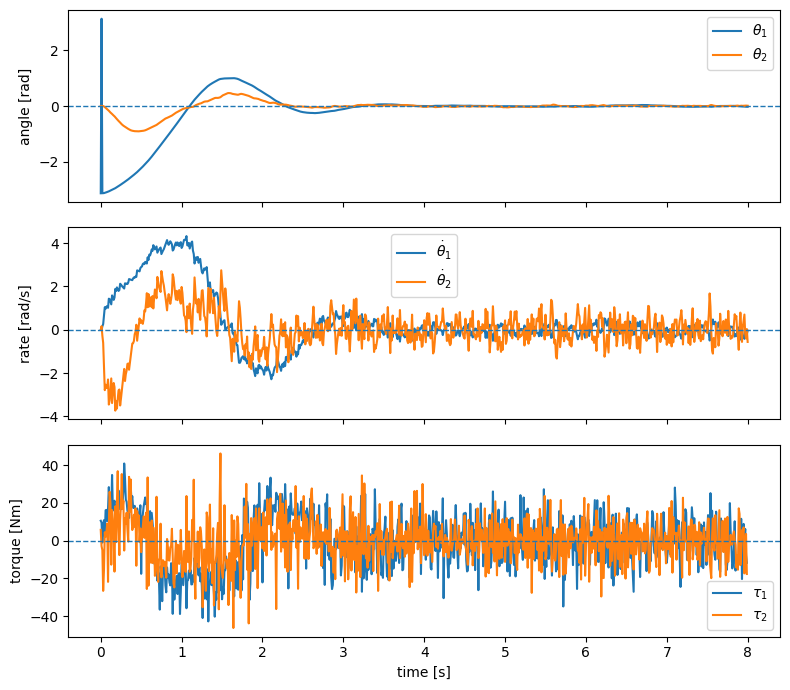

In [4]:
time = np.arange(states.shape[0]) * dt
fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

axs[0].plot(time, (states[:, 0] + jnp.pi) % (2*jnp.pi) - jnp.pi, label=r'$\theta_1$')
axs[0].plot(time, (states[:, 2] + jnp.pi) % (2*jnp.pi) - jnp.pi, label=r'$\theta_2$')
axs[0].axhline(0, ls='--', lw=1); axs[0].legend(); axs[0].set_ylabel('angle [rad]')

axs[1].plot(time, states[:, 1], label=r'$\dot{\theta}_1$')
axs[1].plot(time, states[:, 3], label=r'$\dot{\theta}_2$')
axs[1].axhline(0, ls='--', lw=1); axs[1].legend(); axs[1].set_ylabel('rate [rad/s]')

axs[2].plot(time[:-1], controls[:, 0], label=r'$\tau_1$')
axs[2].plot(time[:-1], controls[:, 1], label=r'$\tau_2$')
axs[2].axhline(0, ls='--', lw=1); axs[2].legend(); axs[2].set_ylabel('torque [Nm]'); axs[2].set_xlabel('time [s]')
plt.tight_layout()
plt.show()



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     7684
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     3362

Total number of variables............................:     2176
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      240
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1924
Total number of inequality c

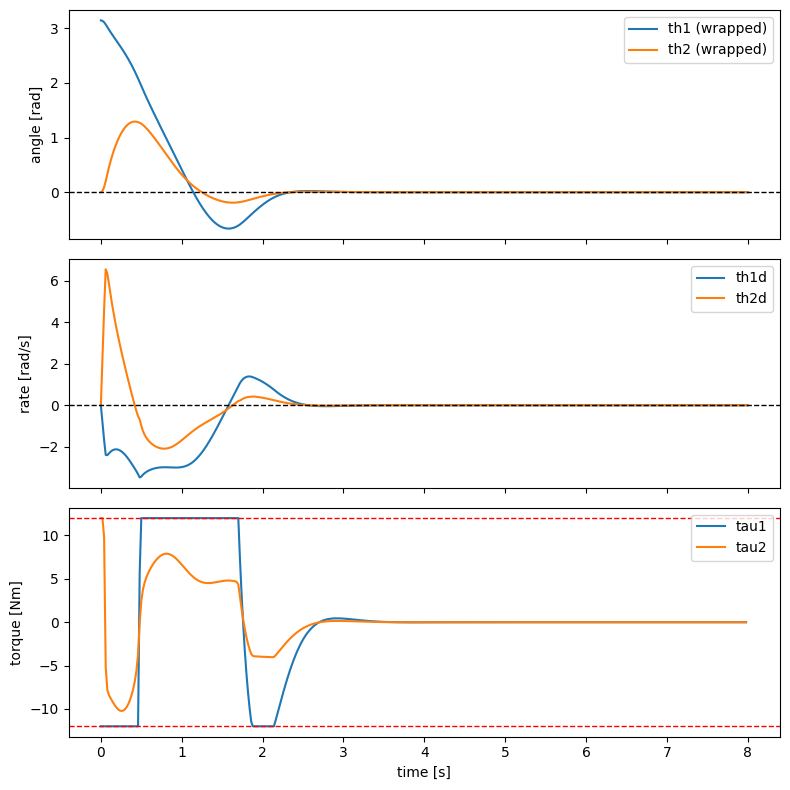

In [5]:
import casadi as cs
import numpy as np
import do_mpc
import matplotlib.pyplot as plt

# -----------------------
# 1) Physical parameters
# -----------------------
g  = 9.81
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
lc1 = 0.5
lc2 = 0.5
I1  = 0.2
I2  = 0.2

# torque limits
u_min = np.array([-12.0, -12.0])
u_max = np.array([+12.0, +12.0])

# reference (upright, zero velocities)
x_ref = np.array([0.0, 0.0, 0.0, 0.0])

# Cost weights (可按需调整，沿用你常用的 Q/QT/R 风格)
Q  = np.diag([60.0, 2.0, 60.0, 2.0])
QT = np.diag([140.0, 5.0, 140.0, 5.0])
R  = np.diag([1e-2, 1e-2])

# 角度包裹（在 cost 里用，避免跨 ±pi 带来的大误差）
def wrap(a):
    # atan2(sin,cos) 是光滑的角度归一化：(-pi, pi]
    return cs.atan2(cs.sin(a), cs.cos(a))

# --------------------------------
# 2) Build do-mpc continuous model
# --------------------------------
model = do_mpc.model.Model('continuous')

# States
th1  = model.set_variable('_x', 'th1')
th1d = model.set_variable('_x', 'th1d')
th2  = model.set_variable('_x', 'th2')
th2d = model.set_variable('_x', 'th2d')

# Inputs
tau1 = model.set_variable('_u', 'tau1')
tau2 = model.set_variable('_u', 'tau2')

# Spong form (CasADi symbols)
c2 = cs.cos(th2)
s2 = cs.sin(th2)

d11 = I1 + I2 + m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2)
d12 = I2 + m2*(lc2**2 + l1*lc2*c2)
d21 = d12
d22 = I2 + m2*lc2**2
D = cs.vertcat(
    cs.hcat([d11, d12]),
    cs.hcat([d21, d22])
)

h = m2*l1*lc2*s2
c1 = -2.0*h*th1d*th2d - h*th2d**2
c2_term = h*th1d**2
Cqd = cs.vertcat(c1, c2_term)

g1 = (m1*lc1 + m2*l1)*g*cs.sin(th1) + m2*lc2*g*cs.sin(th1 + th2)
g2 = m2*lc2*g*cs.sin(th1 + th2)
Gv = cs.vertcat(g1, g2)

tau = cs.vertcat(tau1, tau2)
rhs = tau - Cqd - Gv
ddq = cs.solve(D, rhs)  # [th1dd, th2dd]

# ODEs
model.set_rhs('th1',  th1d)
model.set_rhs('th1d', ddq[0])
model.set_rhs('th2',  th2d)
model.set_rhs('th2d', ddq[1])

model.setup()

# -----------------------
# 3) Setup MPC controller
# -----------------------
mpc = do_mpc.controller.MPC(model)

dt = 0.02
setup_mpc = {
    'n_horizon': 120,
    't_step': dt,
    'state_discretization': 'collocation',
    'collocation_type': 'radau',
    'n_robust': 0,
    'store_full_solution': True,
}
mpc.set_param(**setup_mpc)

# Stage/terminal cost with angle wrapping on position states
e_th1  = wrap(th1 - x_ref[0])
e_th1d = (th1d - x_ref[1])
e_th2  = wrap(th2 - x_ref[2])
e_th2d = (th2d - x_ref[3])

e_vec  = cs.vertcat(e_th1, e_th1d, e_th2, e_th2d)
u_vec  = cs.vertcat(tau1, tau2)

lterm = cs.mtimes([e_vec.T, cs.DM(Q),  e_vec]) + cs.mtimes([u_vec.T, cs.DM(R),  u_vec])
mterm = cs.mtimes([e_vec.T, cs.DM(QT), e_vec])

mpc.set_objective(mterm=mterm, lterm=lterm)
mpc.set_rterm(tau1=1e-4, tau2=1e-4)

# Input bounds
mpc.bounds['lower','_u','tau1'] = u_min[0]
mpc.bounds['upper','_u','tau1'] = u_max[0]
mpc.bounds['lower','_u','tau2'] = u_min[1]
mpc.bounds['upper','_u','tau2'] = u_max[1]

mpc.setup()

# ----------------
simulator = do_mpc.simulator.Simulator(model)
simulator.set_param(t_step=dt)
simulator.setup()

x0 = np.array([np.pi, 0.0, 0.0, 0.0]) 
mpc.x0 = x0
simulator.x0 = x0
mpc.set_initial_guess()

N = int(8.0 / dt)  

X = np.zeros((N+1, 4))
U = np.zeros((N, 2))
T = np.zeros(N+1)
X[0,:] = x0

x = x0.copy()
for k in range(N):
    u = mpc.make_step(x)
    x = simulator.make_step(u)

    X[k+1,:] = x.squeeze()
    U[k,:]   = u.squeeze()
    T[k+1]   = T[k] + dt

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
axs[0].plot(T, (np.angle(np.exp(1j*X[:,0]))), label='th1 (wrapped)')
axs[0].plot(T, (np.angle(np.exp(1j*X[:,2]))), label='th2 (wrapped)')
axs[0].axhline(0.0, ls='--', lw=1, color='k')
axs[0].set_ylabel('angle [rad]')
axs[0].legend()

axs[1].plot(T, X[:,1], label='th1d')
axs[1].plot(T, X[:,3], label='th2d')
axs[1].axhline(0.0, ls='--', lw=1, color='k')
axs[1].set_ylabel('rate [rad/s]')
axs[1].legend()

axs[2].plot(T[:-1], U[:,0], label='tau1')
axs[2].plot(T[:-1], U[:,1], label='tau2')
axs[2].axhline(u_min[0], ls='--', lw=1, color='r')
axs[2].axhline(u_max[0], ls='--', lw=1, color='r')
axs[2].set_ylabel('torque [Nm]')
axs[2].set_xlabel('time [s]')
axs[2].legend()
plt.tight_layout()
plt.show()

## Recurrent Condition Verification

### Expert Data Synthesis

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     7684
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     3362

Total number of variables............................:     2176
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      240
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1924
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  7.2442896e+04 2.66e-15 1.00e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

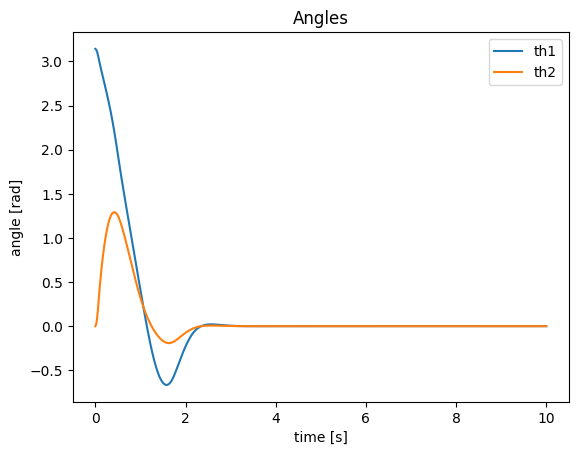

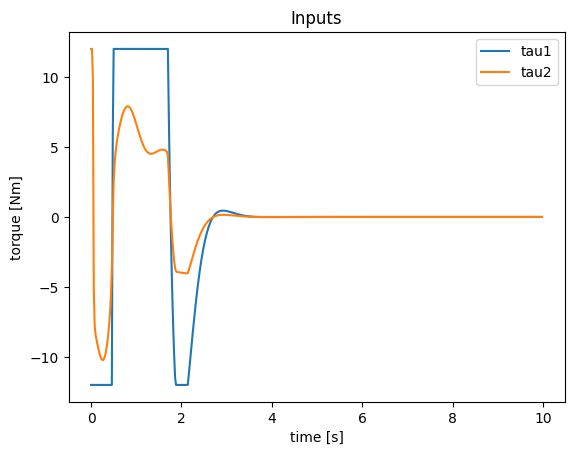

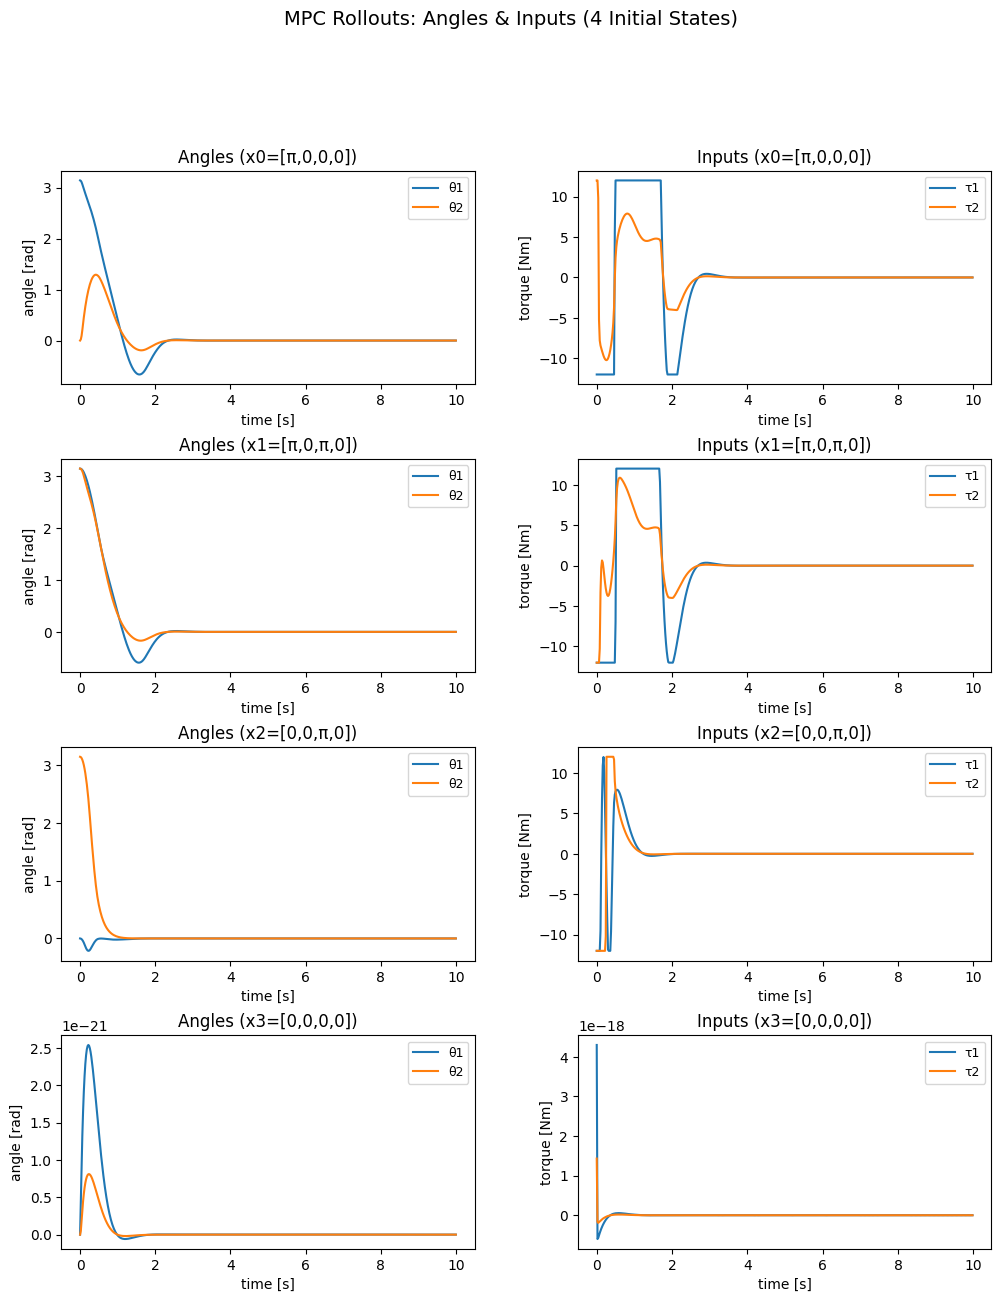

Saved .npy files to: /home/jliu376/myenv/Nonparameric_Hamiltonian_Systems


In [6]:
cfg = DoublePendulumParams(dt=0.02, n_horizon=120)  # defaults already match your script
model, mpc, simulator = build_double_pendulum_mpc(cfg)

simulator.t_step = cfg.dt

x0 = np.array([np.pi, 0.0, 0.0, 0.0], dtype=float)
x1 = np.array([np.pi, 0.0, np.pi, 0.0], dtype=float)
x2 = np.array([0.0, 0.0, np.pi, 0.0], dtype=float)
x3 = np.array([0.0, 0.0, 0.0, 0.0], dtype=float)

T0, X0, U0 = rollout_mpc(mpc, simulator, x0, sim_time=10.0, save_U=True, save_prefix="demo")
T1, X1, U1 = rollout_mpc(mpc, simulator, x1, sim_time=10.0, save_U=True, save_prefix="demo")
T2, X2, U2 = rollout_mpc(mpc, simulator, x2, sim_time=10.0, save_U=True, save_prefix="demo")
T3, X3, U3 = rollout_mpc(mpc, simulator, x3, sim_time=10.0, save_U=True, save_prefix="demo")

print("Shapes -> T:", T0.shape, " X:", X0.shape, " U:", U0.shape)
print("First control:", U0[0])
plt.figure()
plt.plot(T0, X0[:,0], label='th1')
plt.plot(T0, X0[:,2], label='th2')
plt.legend()
plt.xlabel('time [s]'); plt.ylabel('angle [rad]')
plt.title('Angles')

plt.figure()
plt.plot(T0[:-1], U0[:,0], label='tau1')
plt.plot(T0[:-1], U0[:,1], label='tau2')
plt.legend()
plt.xlabel('time [s]'); plt.ylabel('torque [Nm]')
plt.title('Inputs')
plt.show()

import matplotlib.pyplot as plt

cases = [
    ("x0=[π,0,0,0]",   T0, X0, U0),
    ("x1=[π,0,π,0]",   T1, X1, U1),
    ("x2=[0,0,π,0]",   T2, X2, U2),
    ("x3=[0,0,0,0]",   T3, X3, U3),
]

fig = plt.figure(figsize=(12, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.25)

for r, (name, T, X, U) in enumerate(cases):
    ax_th = fig.add_subplot(gs[r, 0])
    ax_th.plot(T, X[:, 0], label='θ1')
    ax_th.plot(T, X[:, 2], label='θ2')
    ax_th.set_title(f'Angles ({name})')
    ax_th.set_xlabel('time [s]')
    ax_th.set_ylabel('angle [rad]')
    ax_th.legend(loc='best', fontsize=9)

    ax_u = fig.add_subplot(gs[r, 1])
    t_u = T[:-1] if U.shape[0] == T.shape[0]-1 else T[:U.shape[0]]
    ax_u.plot(t_u, U[:, 0], label='τ1')
    ax_u.plot(t_u, U[:, 1], label='τ2')
    ax_u.set_title(f'Inputs ({name})')
    ax_u.set_xlabel('time [s]')
    ax_u.set_ylabel('torque [Nm]')
    ax_u.legend(loc='best', fontsize=9)

fig.suptitle('MPC Rollouts: Angles & Inputs (4 Initial States)', y=0.995, fontsize=14)
plt.show()

import os
import numpy as np

save_dir = os.path.expanduser('~/myenv/Nonparameric_Hamiltonian_Systems')
os.makedirs(save_dir, exist_ok=True)

names = {
    "x0_pi_0_0_0"  : (T0, X0, U0),
    "x1_pi_0_pi_0" : (T1, X1, U1),
    "x2_0_0_pi_0"  : (T2, X2, U2),
    "x3_0_0_0_0"   : (T3, X3, U3),
}

for name, (T, X, U) in names.items():
    np.save(os.path.join(save_dir, f"T_{name}.npy"), T)
    np.save(os.path.join(save_dir, f"X_{name}.npy"), X)
    np.save(os.path.join(save_dir, f"U_{name}.npy"), U)

print("Saved .npy files to:", save_dir)

### Radius Computation based on Energy

In [ ]:
L_H = 660.56

